In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Set plot style
sns.set(style='whitegrid')


In [2]:
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Churn Rate & Retention Rate
total_customers = len(df)
churned = df[df['Churn'] == 'Yes']
churn_rate = len(churned) / total_customers
retention_rate = 1 - churn_rate

print(f"Churn Rate: {churn_rate:.2%}")
print(f"Retention Rate: {retention_rate:.2%}")


Churn Rate: 26.54%
Retention Rate: 73.46%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_260\711859143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


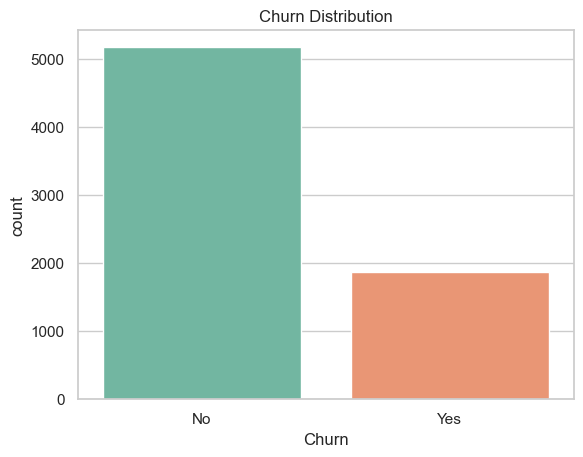

In [4]:
#Visualize Churn Distribution
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.show()


In [5]:
#Customer Lifetime Value (CLV)
avg_monthly_charge = df['MonthlyCharges'].mean()
avg_tenure = df['tenure'].mean()
clv = avg_monthly_charge * avg_tenure

print(f"Estimated CLV: ${clv:.2f}")


Estimated CLV: $2096.41


In [6]:
#Monthly Revenue Lost to Churn
mrr_lost = churned['MonthlyCharges'].sum()
print(f"Monthly Recurring Revenue Lost: ${mrr_lost:.2f}")


Monthly Recurring Revenue Lost: $139130.85


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_260\1011150517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_churn, x='Contract', y='Churn', palette='coolwarm')


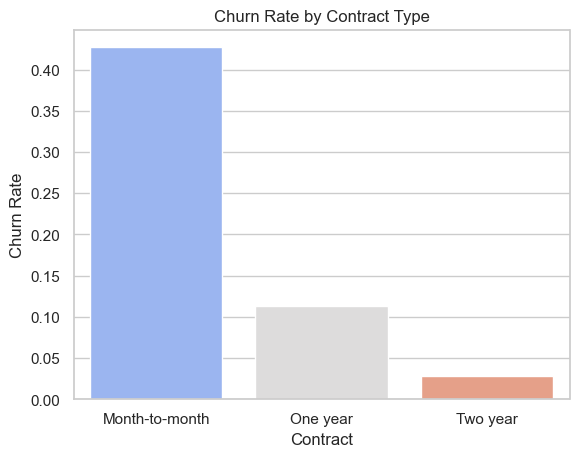

In [7]:
# #Churn by Segment (e.g., Contract Type)
segment_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
sns.barplot(data=segment_churn, x='Contract', y='Churn', palette='coolwarm')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()


In [ ]:
#Early Churn Rate (Tenure ≤ 3 months)
early_churn = df[(df['tenure'] <= 3) & (df['Churn'] == 'Yes')]
early_churn_rate = len(early_churn) / len(df[df['tenure'] <= 3])
print(f"Early Churn Rate (≤ 3 months): {early_churn_rate:.2%}")
